# TPX1 Uncertainty Calculation - Real Data Test

This notebook tests the `compute_counts_with_uncertainty()` function with real VENUS data.

**Data source:** `/Users/8cz/SNS/VENUS/IPTS-35167/shared/autoreduce/mcp/images/Run_9018`

**Tests:**
1. Full image (no ROI)
2. Middle 50% ROI

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

# iBeatles imports
from ibeatles.core.io.data_loading import load_data_from_folder
from ibeatles.core.detector import compute_counts_with_uncertainty

/Users/8cz/github.com/ornlneutronimaging/iBeatles/.pixi/envs/default/lib/python3.11/site-packages/neutronbraggedge/experiment_handler/tof.py:61: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  if units is not 's':


## 1. Define Data Paths

In [ ]:
# NOTE: adjust the PATH to data directory as needed
data_dir = Path("/Users/8cz/SNS/VENUS/IPTS-35167/shared/autoreduce/mcp/images/Run_9018")

# Find metadata files
shutter_count_file = list(data_dir.glob("*_ShutterCount.txt"))[0]
spectra_file = list(data_dir.glob("*_Spectra.txt"))[0]

print(f"Data directory: {data_dir}")
print(f"Shutter count file: {shutter_count_file.name}")
print(f"Spectra file: {spectra_file.name}")

Data directory: /Users/8cz/SNS/VENUS/IPTS-35167/shared/autoreduce/mcp/images/Run_9018
Shutter count file: Run_9018_20250521_May21_2025_Thin_Cu_2cm_5_0C_0_7Angsmin_0005_3368015_ShutterCount.txt
Spectra file: Run_9018_20250521_May21_2025_Thin_Cu_2cm_5_0C_0_7Angsmin_0005_3368015_Spectra.txt


## 2. Load TIFF Stack

In [3]:
# Load TIFF stack using iBeatles loader
print("Loading TIFF stack (this may take a while)...")
data = load_data_from_folder(str(data_dir), file_extension=".tif")

tiff_stack = data["data"]
print(f"Loaded {tiff_stack.shape[0]} frames, image size: {tiff_stack.shape[1]}x{tiff_stack.shape[2]}")

Loading TIFF stack (this may take a while)...


  0%|          | 0/2787 [00:00<?, ?it/s]

2025-12-17 13:04:51.714 | INFO     | ibeatles.core.io.data_loading:load_data_from_folder:258 - Loaded 2787 images from folder: /Users/8cz/SNS/VENUS/IPTS-35167/shared/autoreduce/mcp/images/Run_9018


Loaded 2787 frames, image size: 512x512


## 3. Load Spectra (TOF array)

In [4]:
# Load spectra file (comma-separated with header)
spectra_df = pd.read_csv(spectra_file)
print(f"Spectra file columns: {list(spectra_df.columns)}")
print(f"Number of rows: {len(spectra_df)}")

# Extract TOF array (shutter_time column)
tof_array = spectra_df["shutter_time"].values
print(f"TOF range: {tof_array.min():.2e} to {tof_array.max():.2e} seconds")

# Verify frame count matches
assert len(tof_array) == tiff_stack.shape[0], f"Mismatch: {len(tof_array)} TOF values vs {tiff_stack.shape[0]} frames"
print("✓ TOF array length matches frame count")

Spectra file columns: ['shutter_time', 'counts']
Number of rows: 2787
TOF range: 6.08e-06 to 1.59e-02 seconds
✓ TOF array length matches frame count


## 4. Inspect Shutter Counts

In [5]:
# Preview shutter counts file
from ibeatles.core.detector.uncertainty import load_shutter_counts

shutter_df = load_shutter_counts(shutter_count_file)
print("Shutter counts:")
print(shutter_df)

2025-12-17 13:04:59.321 | INFO     | ibeatles.core.detector.uncertainty:load_shutter_counts:85 - Loaded shutter counts: 3 shutter periods, counts range [203133, 203530]


Shutter counts:
   shutter_index  shutter_counts  shutter_n_ratio
0              0          203530         1.000000
1              1          203357         0.999150
2              2          203133         0.998049


## 5. Preview Data

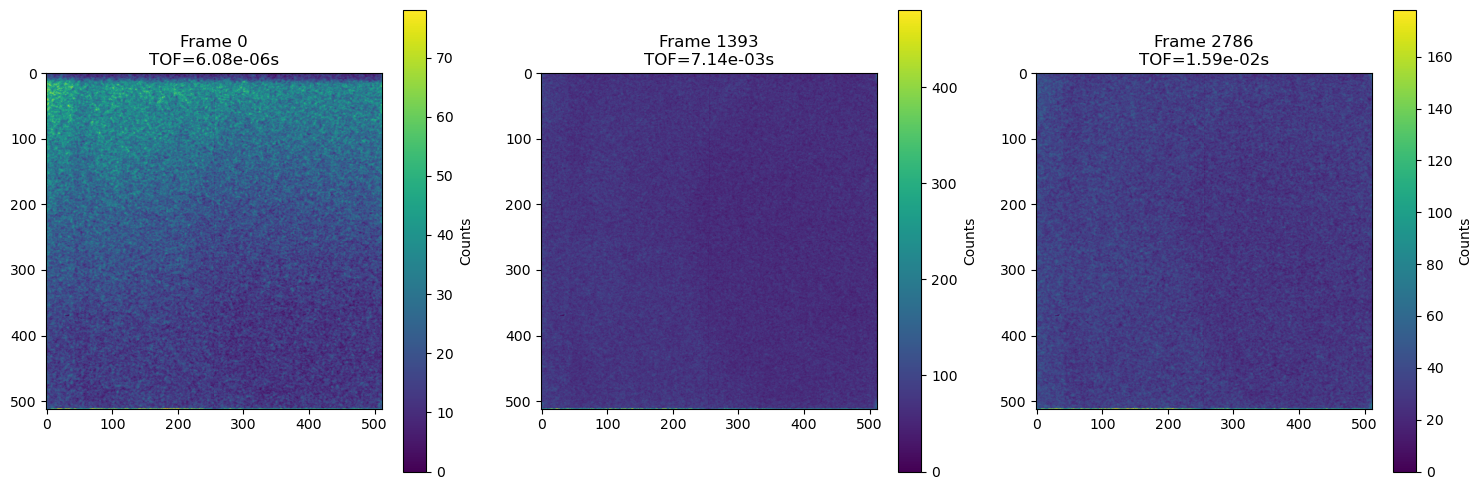

Data range: [0.0, 790.0]
Mean counts: 70.5


In [6]:
# Show sample images
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

frame_indices = [0, tiff_stack.shape[0]//2, tiff_stack.shape[0]-1]
for ax, idx in zip(axes, frame_indices):
    im = ax.imshow(tiff_stack[idx], cmap='viridis')
    ax.set_title(f"Frame {idx}\nTOF={tof_array[idx]:.2e}s")
    plt.colorbar(im, ax=ax, label='Counts')

plt.tight_layout()
plt.show()

print(f"Data range: [{tiff_stack.min():.1f}, {tiff_stack.max():.1f}]")
print(f"Mean counts: {tiff_stack.mean():.1f}")

## 6. Test 1: Full Image (No ROI)

In [7]:
%%time
# Compute uncertainty for full image
print("Computing uncertainty for full image...")
result_full = compute_counts_with_uncertainty(
    tiff_stack=tiff_stack,
    tof_array=tof_array,
    shutter_counts_file=shutter_count_file,
    roi_mask=None,  # Use all pixels
)

print(f"\nResult shape: {result_full.shape}")
print(result_full.head(10))

Computing uncertainty for full image...


2025-12-17 13:05:07.196 | INFO     | ibeatles.core.detector.uncertainty:load_shutter_counts:85 - Loaded shutter counts: 3 shutter periods, counts range [203133, 203530]
2025-12-17 13:05:07.198 | INFO     | ibeatles.core.detector.uncertainty:compute_counts_with_uncertainty:291 - Using shutter period 0: counts=203530, ratio=1.0000
2025-12-17 13:05:07.198 | INFO     | ibeatles.core.detector.uncertainty:compute_counts_with_uncertainty:296 - No ROI mask provided, using all pixels
2025-12-17 13:05:07.198 | INFO     | ibeatles.core.detector.uncertainty:compute_counts_with_uncertainty:307 - Computing occupancy from corrected counts...
2025-12-17 13:05:18.883 | INFO     | ibeatles.core.detector.uncertainty:compute_counts_with_uncertainty:311 - Computing variance...
2025-12-17 13:05:36.665 | INFO     | ibeatles.core.detector.uncertainty:compute_counts_with_uncertainty:315 - Aggregating over ROI...
2025-12-17 13:05:40.859 | INFO     | ibeatles.core.detector.uncertainty:compute_counts_with_uncerta


Result shape: (2787, 3)
        tof        counts  uncertainty
0  0.000006  5.540009e+06  2353.868727
1  0.000011  5.639762e+06  2375.111228
2  0.000016  5.750928e+06  2398.554742
3  0.000021  5.845183e+06  2418.284440
4  0.000027  5.961704e+06  2442.429514
5  0.000032  6.053651e+06  2461.355998
6  0.000037  6.202597e+06  2491.622009
7  0.000042  6.324378e+06  2516.138388
8  0.000047  6.460863e+06  2543.323340
9  0.000052  6.601137e+06  2570.971178
CPU times: user 7.82 s, sys: 19.7 s, total: 27.6 s
Wall time: 35.7 s


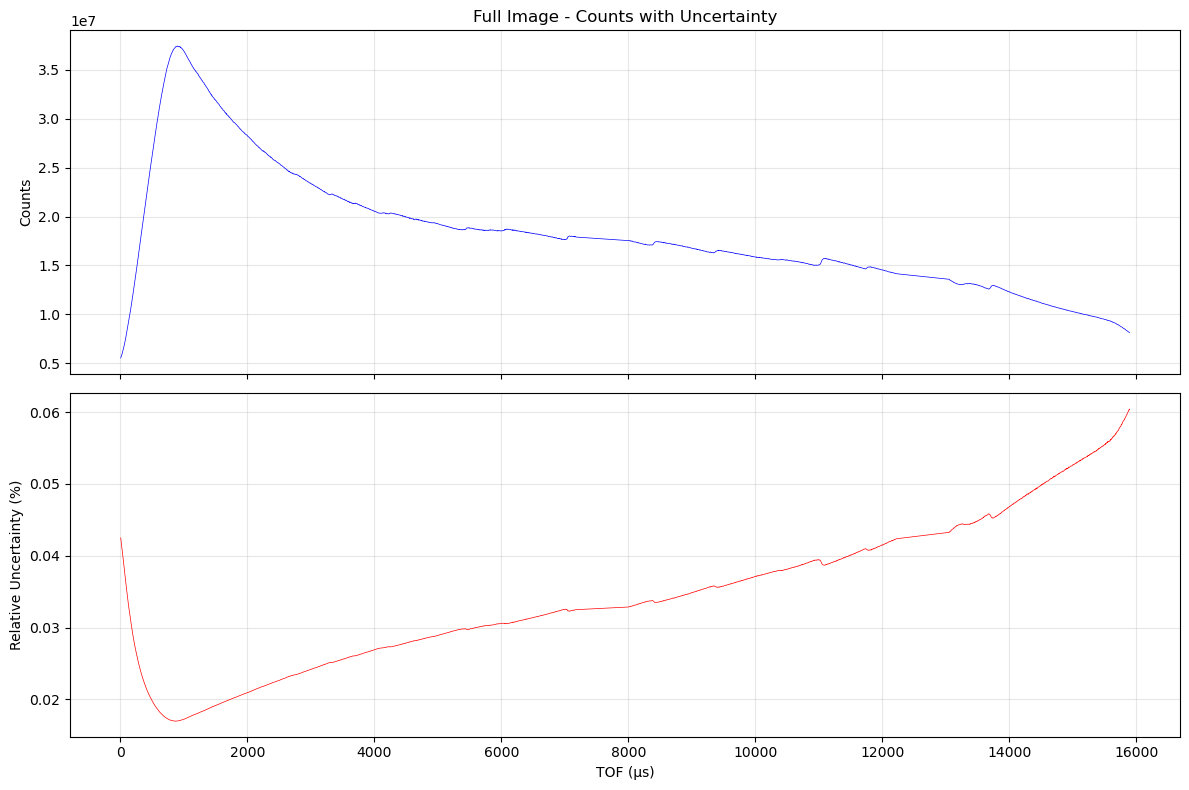

Mean relative uncertainty: 0.03%
Relative uncertainty range: [0.02%, 0.06%]


In [8]:
# Plot full image results
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Counts vs TOF
ax1 = axes[0]
ax1.plot(result_full["tof"] * 1e6, result_full["counts"], 'b-', linewidth=0.5)
ax1.set_ylabel("Counts")
ax1.set_title("Full Image - Counts with Uncertainty")
ax1.grid(True, alpha=0.3)

# Relative uncertainty vs TOF
ax2 = axes[1]
rel_unc = result_full["uncertainty"] / result_full["counts"] * 100
ax2.plot(result_full["tof"] * 1e6, rel_unc, 'r-', linewidth=0.5)
ax2.set_xlabel("TOF (μs)")
ax2.set_ylabel("Relative Uncertainty (%)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mean relative uncertainty: {rel_unc.mean():.2f}%")
print(f"Relative uncertainty range: [{rel_unc.min():.2f}%, {rel_unc.max():.2f}%]")

## 7. Test 2: Middle 50% ROI

Image size: 512x512 = 262144 pixels
ROI size: 256x256 = 65536 pixels
ROI coverage: 25.0%


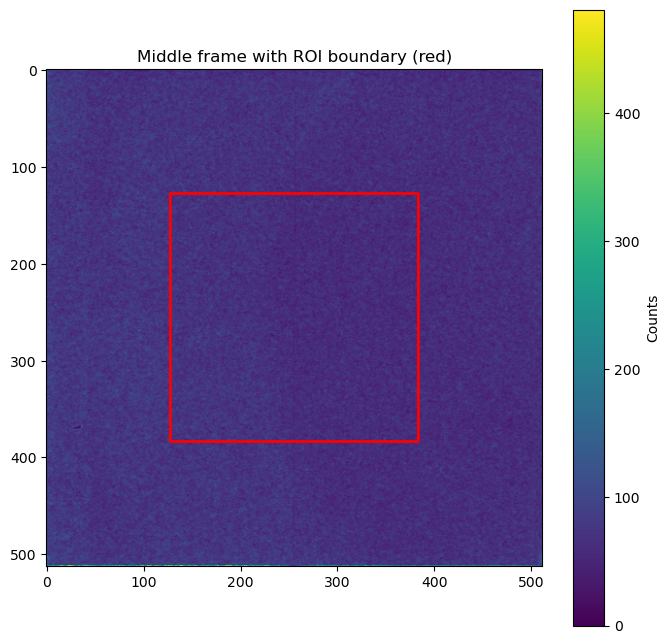

In [10]:
# Define middle 50% ROI
height, width = tiff_stack.shape[1], tiff_stack.shape[2]

# Calculate 25% margins on each side to get middle 50%
margin_y = height // 4
margin_x = width // 4

roi_mask = np.zeros((height, width), dtype=bool)
roi_mask[margin_y:height-margin_y, margin_x:width-margin_x] = True

n_roi_pixels = np.sum(roi_mask)
n_total_pixels = height * width
print(f"Image size: {height}x{width} = {n_total_pixels} pixels")
print(f"ROI size: {height-2*margin_y}x{width-2*margin_x} = {n_roi_pixels} pixels")
print(f"ROI coverage: {n_roi_pixels/n_total_pixels*100:.1f}%")

# Visualize ROI
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(tiff_stack[tiff_stack.shape[0]//2], cmap='viridis')
ax.contour(roi_mask, colors='red', linewidths=2)
ax.set_title("Middle frame with ROI boundary (red)")
plt.colorbar(im, ax=ax, label='Counts')
plt.show()

In [11]:
%%time
# Compute uncertainty for ROI
print("Computing uncertainty for middle 50% ROI...")
result_roi = compute_counts_with_uncertainty(
    tiff_stack=tiff_stack,
    tof_array=tof_array,
    shutter_counts_file=shutter_count_file,
    roi_mask=roi_mask,
)

print(f"\nResult shape: {result_roi.shape}")
print(result_roi.head(10))

Computing uncertainty for middle 50% ROI...


2025-12-17 13:08:03.405 | INFO     | ibeatles.core.detector.uncertainty:load_shutter_counts:85 - Loaded shutter counts: 3 shutter periods, counts range [203133, 203530]
2025-12-17 13:08:03.406 | INFO     | ibeatles.core.detector.uncertainty:compute_counts_with_uncertainty:291 - Using shutter period 0: counts=203530, ratio=1.0000
2025-12-17 13:08:03.406 | INFO     | ibeatles.core.detector.uncertainty:compute_counts_with_uncertainty:304 - ROI contains 65536 pixels
2025-12-17 13:08:03.406 | INFO     | ibeatles.core.detector.uncertainty:compute_counts_with_uncertainty:307 - Computing occupancy from corrected counts...
2025-12-17 13:08:14.637 | INFO     | ibeatles.core.detector.uncertainty:compute_counts_with_uncertainty:311 - Computing variance...
2025-12-17 13:08:31.043 | INFO     | ibeatles.core.detector.uncertainty:compute_counts_with_uncertainty:315 - Aggregating over ROI...
2025-12-17 13:08:32.473 | INFO     | ibeatles.core.detector.uncertainty:compute_counts_with_uncertainty:337 - Co


Result shape: (2787, 3)
        tof        counts  uncertainty
0  0.000006  1.239405e+06  1113.342625
1  0.000011  1.274223e+06  1128.929329
2  0.000016  1.306444e+06  1143.172506
3  0.000021  1.331512e+06  1154.148976
4  0.000027  1.361728e+06  1167.233480
5  0.000032  1.389832e+06  1179.281518
6  0.000037  1.425165e+06  1194.244584
7  0.000042  1.463338e+06  1210.202738
8  0.000047  1.502255e+06  1226.261767
9  0.000052  1.539372e+06  1241.393086
CPU times: user 7.06 s, sys: 17.2 s, total: 24.3 s
Wall time: 38.2 s


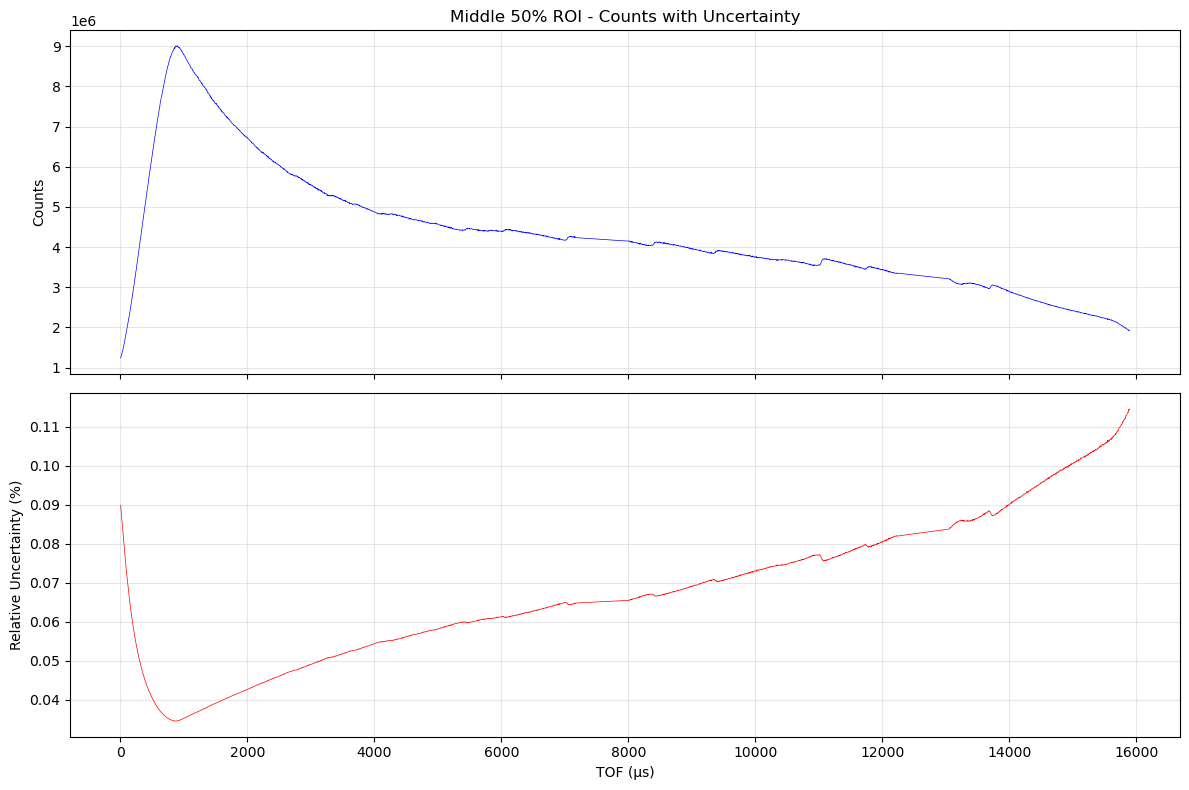

Mean relative uncertainty: 0.07%
Relative uncertainty range: [0.03%, 0.11%]


In [12]:
# Plot ROI results
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Counts vs TOF
ax1 = axes[0]
ax1.plot(result_roi["tof"] * 1e6, result_roi["counts"], 'b-', linewidth=0.5)
ax1.set_ylabel("Counts")
ax1.set_title("Middle 50% ROI - Counts with Uncertainty")
ax1.grid(True, alpha=0.3)

# Relative uncertainty vs TOF
ax2 = axes[1]
rel_unc_roi = result_roi["uncertainty"] / result_roi["counts"] * 100
ax2.plot(result_roi["tof"] * 1e6, rel_unc_roi, 'r-', linewidth=0.5)
ax2.set_xlabel("TOF (μs)")
ax2.set_ylabel("Relative Uncertainty (%)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mean relative uncertainty: {rel_unc_roi.mean():.2f}%")
print(f"Relative uncertainty range: [{rel_unc_roi.min():.2f}%, {rel_unc_roi.max():.2f}%]")

## 8. Compare Full Image vs ROI

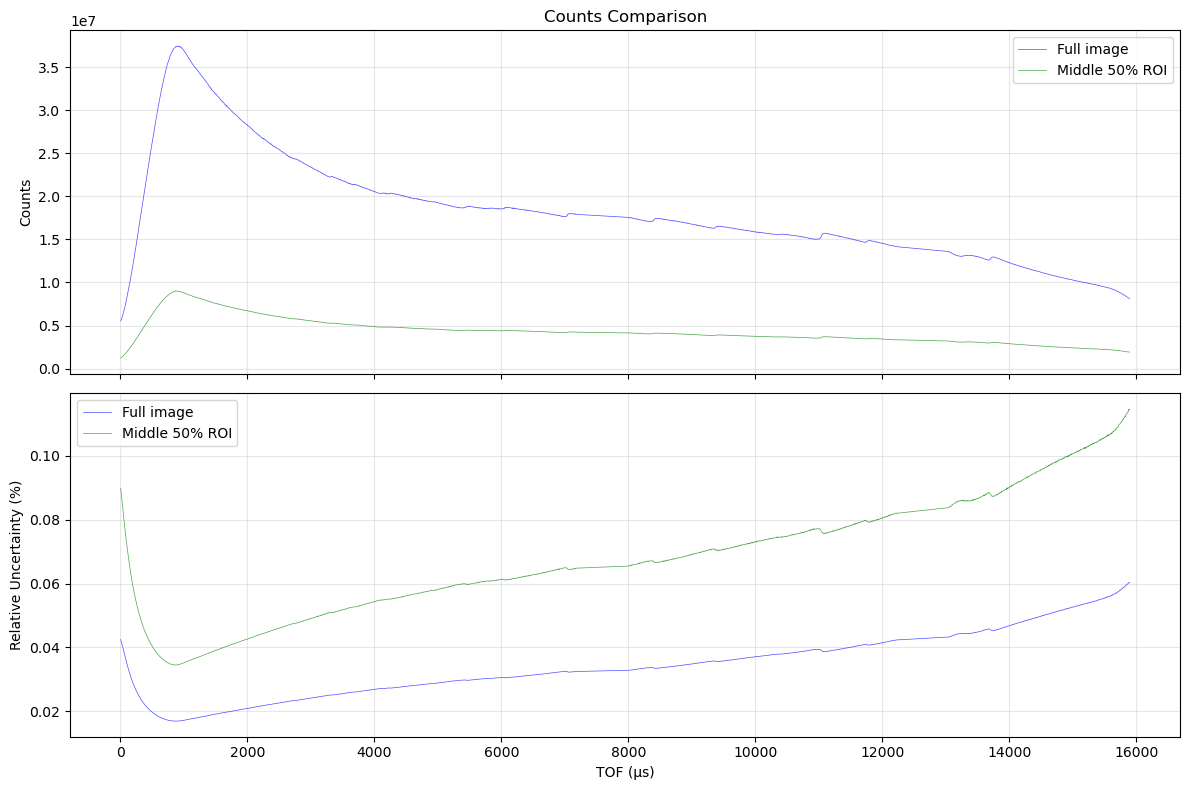


=== Summary ===

Full image (262144 pixels):
  Mean counts: 18487051.8
  Mean uncertainty: 5691.1
  Mean relative uncertainty: 0.03%

Middle 50% ROI (65536 pixels):
  Mean counts: 4382048.2
  Mean uncertainty: 2674.2
  Mean relative uncertainty: 0.07%

✓ ROI relative uncertainty is higher than full image (as expected for smaller pixel count)


In [13]:
# Compare the two results
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Counts comparison
ax1 = axes[0]
ax1.plot(result_full["tof"] * 1e6, result_full["counts"], 'b-', linewidth=0.5, label='Full image', alpha=0.7)
ax1.plot(result_roi["tof"] * 1e6, result_roi["counts"], 'g-', linewidth=0.5, label='Middle 50% ROI', alpha=0.7)
ax1.set_ylabel("Counts")
ax1.set_title("Counts Comparison")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Relative uncertainty comparison
ax2 = axes[1]
rel_unc_full = result_full["uncertainty"] / result_full["counts"] * 100
rel_unc_roi = result_roi["uncertainty"] / result_roi["counts"] * 100
ax2.plot(result_full["tof"] * 1e6, rel_unc_full, 'b-', linewidth=0.5, label='Full image', alpha=0.7)
ax2.plot(result_roi["tof"] * 1e6, rel_unc_roi, 'g-', linewidth=0.5, label='Middle 50% ROI', alpha=0.7)
ax2.set_xlabel("TOF (μs)")
ax2.set_ylabel("Relative Uncertainty (%)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("\n=== Summary ===")
print(f"\nFull image ({n_total_pixels} pixels):")
print(f"  Mean counts: {result_full['counts'].mean():.1f}")
print(f"  Mean uncertainty: {result_full['uncertainty'].mean():.1f}")
print(f"  Mean relative uncertainty: {rel_unc_full.mean():.2f}%")

print(f"\nMiddle 50% ROI ({n_roi_pixels} pixels):")
print(f"  Mean counts: {result_roi['counts'].mean():.1f}")
print(f"  Mean uncertainty: {result_roi['uncertainty'].mean():.1f}")
print(f"  Mean relative uncertainty: {rel_unc_roi.mean():.2f}%")

# Expected: smaller ROI should have larger relative uncertainty
print(f"\n✓ ROI relative uncertainty is {'higher' if rel_unc_roi.mean() > rel_unc_full.mean() else 'lower'} than full image (as expected for smaller pixel count)")

## 9. Export Results to CSV

In [14]:
# Create output directory
output_dir = Path("./uncertainty_test_output")
output_dir.mkdir(exist_ok=True)

# Export full image results
full_output = output_dir / "Run_9018_full_image_spectrum.csv"
result_full.to_csv(full_output, index=False)
print(f"Saved: {full_output}")

# Export ROI results
roi_output = output_dir / "Run_9018_middle_50pct_roi_spectrum.csv"
result_roi.to_csv(roi_output, index=False)
print(f"Saved: {roi_output}")

# Show sample of exported data
print("\nSample of exported CSV:")
print(pd.read_csv(full_output).head())

Saved: uncertainty_test_output/Run_9018_full_image_spectrum.csv
Saved: uncertainty_test_output/Run_9018_middle_50pct_roi_spectrum.csv

Sample of exported CSV:
        tof        counts  uncertainty
0  0.000006  5.540009e+06  2353.868727
1  0.000011  5.639762e+06  2375.111228
2  0.000016  5.750928e+06  2398.554742
3  0.000021  5.845183e+06  2418.284440
4  0.000027  5.961704e+06  2442.429514


## 10. Summary

The `compute_counts_with_uncertainty()` function has been tested with real VENUS data.

**Results:**
- Successfully loaded 2787 frames from Run_9018
- Computed uncertainty for full image and middle 50% ROI
- Exported results to CSV files with columns: tof, counts, uncertainty

**Observations:**
- Relative uncertainty is higher for smaller ROI (fewer pixels = less statistics)
- The uncertainty calculation completes in reasonable time for ~3000 frames